In [90]:
import sys
import numpy as np
import torch
from pathlib import Path

sys.path.insert(0, str(Path(".").resolve()))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from Utils.utils import sun_weights

# Use same wavelength range as datasets
wavelengths = np.linspace(300, 1100, 801)
wls_t = torch.tensor(wavelengths, dtype=torch.float32)
I_am15g = sun_weights(wls_t).numpy()   # W/m^2/nm

# The integrand: lambda * I_AM1.5G  (proportional to photon flux per nm)
integrand = wavelengths * I_am15g      # nm * W/m^2/nm = W*nm/m^2/nm = W/m^2

# --- Plot ---
plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
})

fig, ax1 = plt.subplots(figsize=(9, 4.5))

# Fill under the integrand curve, coloured by wavelength using a spectral colormap
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

# Build line segments coloured by wavelength
points = np.array([wavelengths, integrand]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
norm = Normalize(vmin=300, vmax=1100)
lc = LineCollection(segments, cmap='turbo', norm=norm, linewidth=2.5, zorder=3)
lc.set_array((wavelengths[:-1] + wavelengths[1:]) / 2)
ax1.add_collection(lc)

# Fill area under curve in a light grey
ax1.fill_between(wavelengths, integrand, alpha=0.15, color='gray')

# Also plot I_AM1.5G as a dashed secondary curve on twin axis
ax2 = ax1.twinx()
ax2.plot(wavelengths, I_am15g, color='gray', linestyle='--', linewidth=1.2, alpha=0.6, label=r'$I_{\mathrm{AM1.5g}}(\lambda)$')
ax2.set_ylabel(r'$I_{\mathrm{AM1.5g}}(\lambda)$  (W m$^{-2}$ nm$^{-1}$)', color='gray', fontsize=11)
ax2.tick_params(axis='y', labelcolor='gray')
ax2.set_ylim(0, None)
ax2.legend(loc='upper right', fontsize=10)

ax1.set_xlim(300, 1100)
ax1.set_ylim(0, None)
ax1.set_xlabel(r'Wavelength $\lambda$ (nm)')
ax1.set_ylabel(r'$\lambda \cdot I_{\mathrm{AM1.5g}}(\lambda)$  (W m$^{-2}$)')
ax1.set_title(r'Solar Photon Flux Integrand $\lambda \cdot I_{\mathrm{AM1.5g}}(\lambda)$')
ax1.grid(True, linestyle=':', alpha=0.5, zorder=0)


cbar = fig.colorbar(lc, ax=ax2, pad=0.12)
cbar.set_label('Wavelength (nm)', fontsize=10)

plt.tight_layout()
out = Path("../Report/figures/jsc_integrand_am15g.pdf")
out.parent.mkdir(exist_ok=True)
plt.savefig(out, dpi=200, bbox_inches='tight')
plt.savefig(str(out).replace('.pdf', '.png'), dpi=200, bbox_inches='tight')
plt.close()
print(f"Saved to {out}")

Saved to ../Report/figures/jsc_integrand_am15g.pdf


In [167]:
import numpy as np
import torch
from matplotlib import pyplot as plt
import torcwa
from tqdm.notebook import tqdm
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from Utils.utils import *

%load_ext line_profiler

# Hardware
# If GPU support TF32 tensor core, the matmul operation is faster than FP32 but with less precision.
# If you need accurate operation, you have to disable the flag below.
torch.backends.cuda.matmul.allow_tf32 = False
sim_dtype = torch.complex64
geo_dtype = torch.float32
device = torch.device('cuda')

# Simulation environment
# light
eps = 1e-3
inc_ang = (30+eps)*(np.pi/180)   # radian
azi_ang = (0+eps)*(np.pi/180)   # radian

order_N = 20

# geometry
h = 2996.321044921875 #nm
grating_period = 1000 # nm
n = 5000
geometry = [
            14.99967098236084,
            3.767517328262329,
            14.999832153320312,
            5.8183417320251465,
            14.999597549438477,
            4.4703216552734375,
            14.999911308288574,
            4.984400272369385,
            14.999798774719238,
            2.482517719268799,
            14.999898910522461,
            3.766267776489258,
            14.99948501586914,
            0.6276917457580566,
            2996.321044921875,
            0.0
        ]

params_x = torch.tensor(geometry[0:14]).view(-1,2)

x_plot = torch.linspace(-grating_period/2,grating_period/2,501,device=device)
y_plot = torch.clone(x_plot)
z_plot = torch.linspace(-0.3*h,0.5*h,501,device=device)

wavelength = torch.tensor(500+1e-3)
wavelengths = torch.linspace(300, 1100, 161, dtype=float)+1e-3 # for stability

#Sanity check of staircase approximation
num_layers = 5

config = RCWAConfig(grating_period=grating_period, grating_period_y=grating_period,h=h,order_N=order_N, order_N_y=order_N, \
    nx = n, ny = n, n_layers = num_layers, subpixel = True, add_reflector = True, reflector_type = 'pec', inc_ang = inc_ang, azi_ang = azi_ang,grating_material="Si",height_per_layer=5)

#params_x = torch.tensor([[10,0] for i in range(10)], dtype=geo_dtype, device=device)
#params_y = torch.tensor([[0., 0.]], dtype=geo_dtype, device=device)
#params_y = torch.tensor([[10,0] for i in range(10)], dtype=geo_dtype, device=device)
params_y = None

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


## Testing and plotting

In [168]:
wavelength

tensor(500.0010)

In [169]:
sim, sine_eps, A_film, A_grating, Reflectance, Transmittance, P_abs_film, P_abs_grating \
    = get_absorptance(params_x,params_y,wavelength,config)

In [174]:
polarization = [1,1]

(<Figure size 500x800 with 2 Axes>,
 <Axes: title={'center': 'E norm\nxz-plane field distribution at y = 0 nm\n$\\lambda$ = 500.001 nm, pol = [1, 1] in ps-basis \ninc = 30.0°, azi = 0.0°'}, xlabel='x (nm)', ylabel='z (nm)'>)

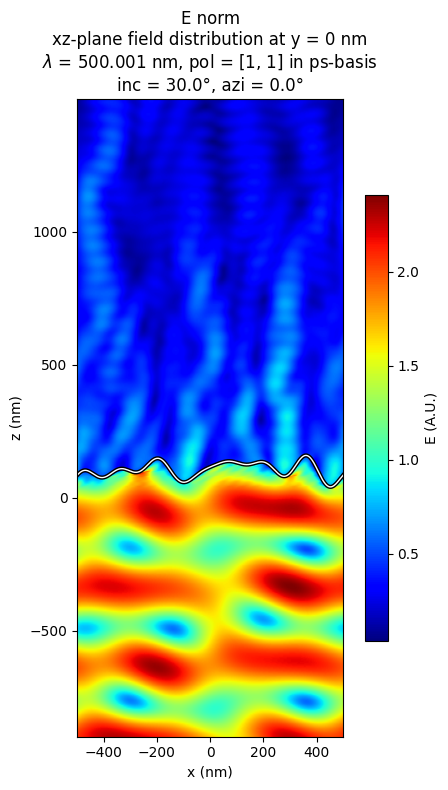

In [175]:
plot_fields(sim, x_plot, z_plot, wavelength, polarization, params_x, params_y, config, field="E norm", thickness=1,y_plot=y_plot, slice_plane='xz', slice_val=0)

In [176]:
A_film + A_grating + Reflectance + Transmittance

tensor([1.0000, 1.0000])

In [177]:
A_film, A_grating, Reflectance, Transmittance

(tensor([0.7227, 0.5394]),
 tensor([0.1094, 0.0940]),
 tensor([0.1680, 0.3666]),
 tensor([-1.5201e-12,  7.7195e-12]))

In [51]:
def objective_function(params):
    """
    Objective function to minimize: negative weighted absorptance.
    """
    transformed = torch.stack((torch.exp(params[:,0]), 2*torch.atan(params[:,1])), dim=-1)
    loss = torch.zeros(1).cuda()
    A_film, A_grating = \
        get_absorptance_curve(transformed,None,wavelengths,config,requires_grad=True)
    loss += -A_film.mean()
    #print(A_film)
    return loss

In [ ]:
#find optimal parameters
init_params_x = torch.tensor([[np.log(10),0] for i in range(7)],dtype=geo_dtype,device=device,requires_grad=True)
opt = torch.optim.AdamW([init_params_x], lr=1e-1,weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.99)

pbar = tqdm(range(500), desc="Optimizing Parameters")
best_loss = float('inf')

for it in pbar:
    opt.zero_grad()
    loss = objective_function(init_params_x)
    loss.backward()
    opt.step()
    scheduler.step()
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_params = init_params_x.detach().clone()
    pbar.set_description(f"Iteration {it}: Loss = {loss.item():.4f} - lr = {scheduler.get_last_lr()[0]:.4f}")

Iteration 499: Loss = -0.4568 - lr = 0.0007: 100%|██████████| 500/500 [29:01<00:00,  3.48s/it]


In [53]:
best_params

tensor([[ 0.9169, -0.2383],
        [ 3.0897, -0.3581],
        [ 3.9206,  0.9387],
        [ 2.8469, -0.6683],
        [-0.4174, -0.4609]], device='cuda:0')

In [54]:
transformed_best_parmas = torch.stack((torch.exp(best_params[:,0]), 2*torch.atan(best_params[:,1])), dim=-1).detach()

In [55]:
transformed_best_parmas

tensor([[ 2.5015, -0.4679],
        [21.9694, -0.6877],
        [50.4291,  1.5075],
        [17.2334, -1.1783],
        [ 0.6587, -0.8637]], device='cuda:0')

In [57]:
sum(transformed_best_parmas[:,0])

tensor(92.7922, device='cuda:0')

In [78]:
wavelengths = torch.linspace(300, 1100, 161, dtype=float)+1e-3 # for stability

In [79]:
A_films, A_grat = get_absorptance_curve(transformed_best_parmas,None,wavelengths,config,show_progress=True)

In [59]:
sim, sine_eps, A_film, A_grating, Reflectance, Transmittance, P_abs_film, P_abs_grating \
    = get_absorptance(transformed_best_parmas,None,wavelength,config)

In [60]:
polarization = [1,0]

(<Figure size 500x800 with 2 Axes>,
 <Axes: title={'center': 'Sz (real abs)\nxz-plane field distribution at y = 0 nm\n$\\lambda$ = 700.001 nm, pol = [1, 0] in ps-basis \ninc = 0.0°, azi = 0.0°'}, xlabel='x (nm)', ylabel='z (nm)'>)

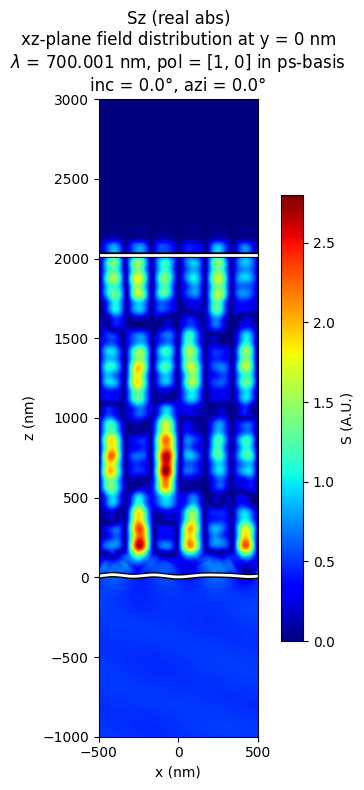

In [68]:
plot_fields(sim, x_plot, z_plot, wavelength, polarization, best_params,None, config, field="Sz", thickness=2,y_plot=y_plot, slice_plane='xz', slice_val=0)

In [69]:
A_film

tensor([0.9591, 0.8234], device='cuda:0')

In [82]:
A_films.mean()

tensor(0.4533)

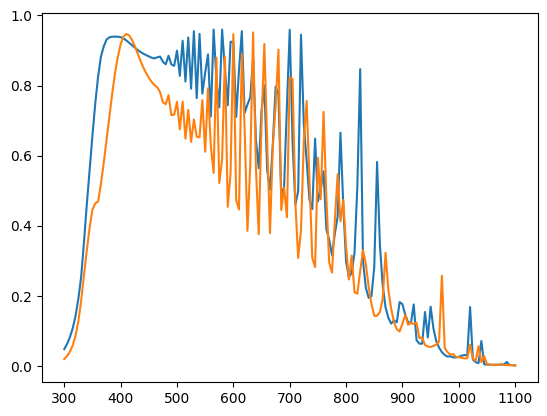

In [80]:
plt.plot(wavelengths.cpu().numpy(),A_films.cpu())

## Absorptance curves

### Num layers

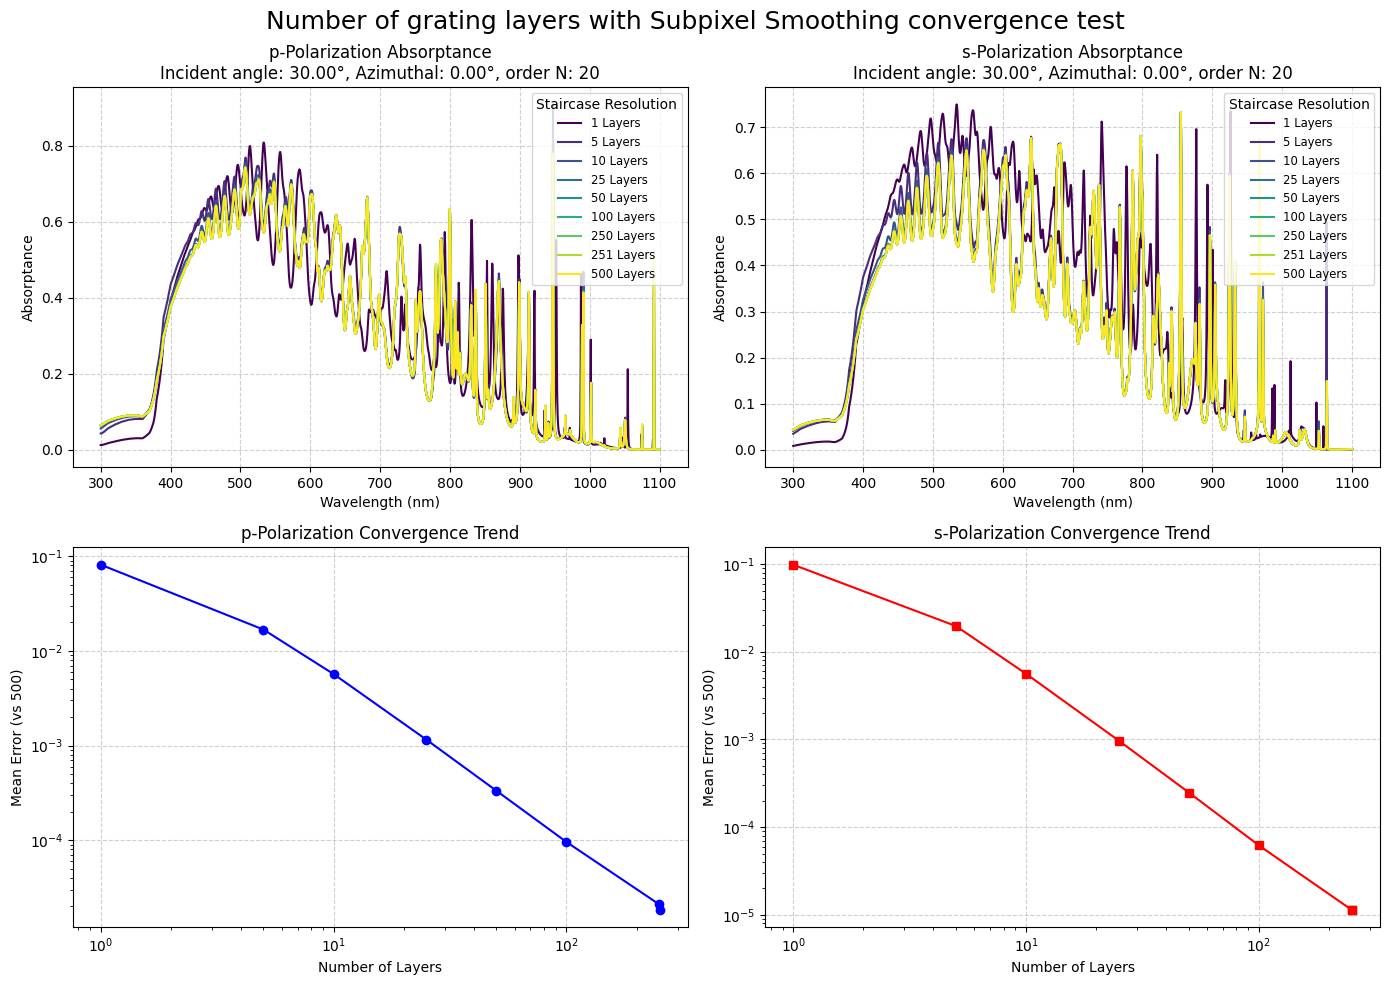

In [109]:
# Load the saved simulation data
saved_data = torch.load('../Data/AbsorptanceCurves/sweep_num_layers_100nm_2026-06-09.pt', weights_only=False)
results = saved_data['results']
metadata = saved_data['metadata']

wavelengths = metadata['wavelengths']
inc_ang = metadata['config']['inc_ang']*180/np.pi
azi_ang = metadata['config']['azi_ang']*180/np.pi

layer_counts = []
key_map = {}

for key in results.keys():
    num = int(key.split('_')[-1])
    order_N = int(key.split('_')[2])
    layer_counts.append(num)
    key_map[num] = key

layer_counts = sorted(layer_counts)
best_layer_count = layer_counts[-1]
best_abs = results[key_map[best_layer_count]]['A_film']

# Pre-calculate mean errors
mean_errors_p = []
mean_errors_s = []
plot_layers = []

for num_layers in layer_counts:
    if num_layers == best_layer_count:
        continue
    curr_abs = results[key_map[num_layers]]['A_film']
    
    # Use torch functions instead of np functions on tensors
    err_p = torch.mean(torch.abs((curr_abs[:, 0] - best_abs[:, 0]))).item()
    err_s = torch.mean(torch.abs((curr_abs[:, 1] - best_abs[:, 1]))).item()
    
    mean_errors_p.append(err_p)
    mean_errors_s.append(err_s)
    plot_layers.append(num_layers)

# Create a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
(ax1_p, ax1_s), (ax2_p, ax2_s) = axs

colors = plt.cm.viridis(np.linspace(0, 1, len(layer_counts)))

for idx, num_layers in enumerate(layer_counts):
    curr_abs = results[key_map[num_layers]]['A_film']
    
    # Top Row: Plot spectra
    ax1_p.plot(wavelengths.cpu(), curr_abs[:, 0].cpu(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5)
    ax1_s.plot(wavelengths.cpu(), curr_abs[:, 1].cpu(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5)
# Format Top Row (Absorptance Spectra)
ax1_p.set_xlabel('Wavelength (nm)')
ax1_p.set_ylabel('Absorptance')
ax1_p.set_title(f'p-Polarization Absorptance\nIncident angle: {inc_ang:.2f}°, Azimuthal: {azi_ang:.2f}°, order N: {order_N}')
ax1_p.grid(True, linestyle='--', alpha=0.6)
ax1_p.legend(title='Staircase Resolution', loc='best', fontsize='small')
#ax1_p.set_yscale('log')

ax1_s.set_xlabel('Wavelength (nm)')
ax1_s.set_ylabel('Absorptance')
ax1_s.set_title(f's-Polarization Absorptance\nIncident angle: {inc_ang:.2f}°, Azimuthal: {azi_ang:.2f}°, order N: {order_N}')
ax1_s.grid(True, linestyle='--', alpha=0.6)
ax1_s.legend(title='Staircase Resolution', loc='best', fontsize='small')
#ax1_s.set_yscale('log')

# Format Bottom Row (Mean Error Convergence)
ax2_p.plot(plot_layers, mean_errors_p, marker='o', linestyle='-', color='blue')
ax2_p.set_xlabel('Number of Layers')
ax2_p.set_ylabel(f'Mean Error (vs {best_layer_count})')
ax2_p.set_title('p-Polarization Convergence Trend')
ax2_p.grid(True, linestyle='--', alpha=0.6)
ax2_p.set_yscale('log')
ax2_p.set_xscale('log')

ax2_s.plot(plot_layers, mean_errors_s, marker='s', linestyle='-', color='red')
ax2_s.set_xlabel('Number of Layers')
ax2_s.set_ylabel(f'Mean Error (vs {best_layer_count})')         
ax2_s.set_title('s-Polarization Convergence Trend')
ax2_s.grid(True, linestyle='--', alpha=0.6)
ax2_s.set_yscale('log')
ax2_s.set_xscale('log')

fig.suptitle('Number of grating layers with Subpixel Smoothing convergence test',fontsize=18)
fig.tight_layout()
fig.savefig('../Data/Num_layer_convergence_fig_100nm')
plt.show()

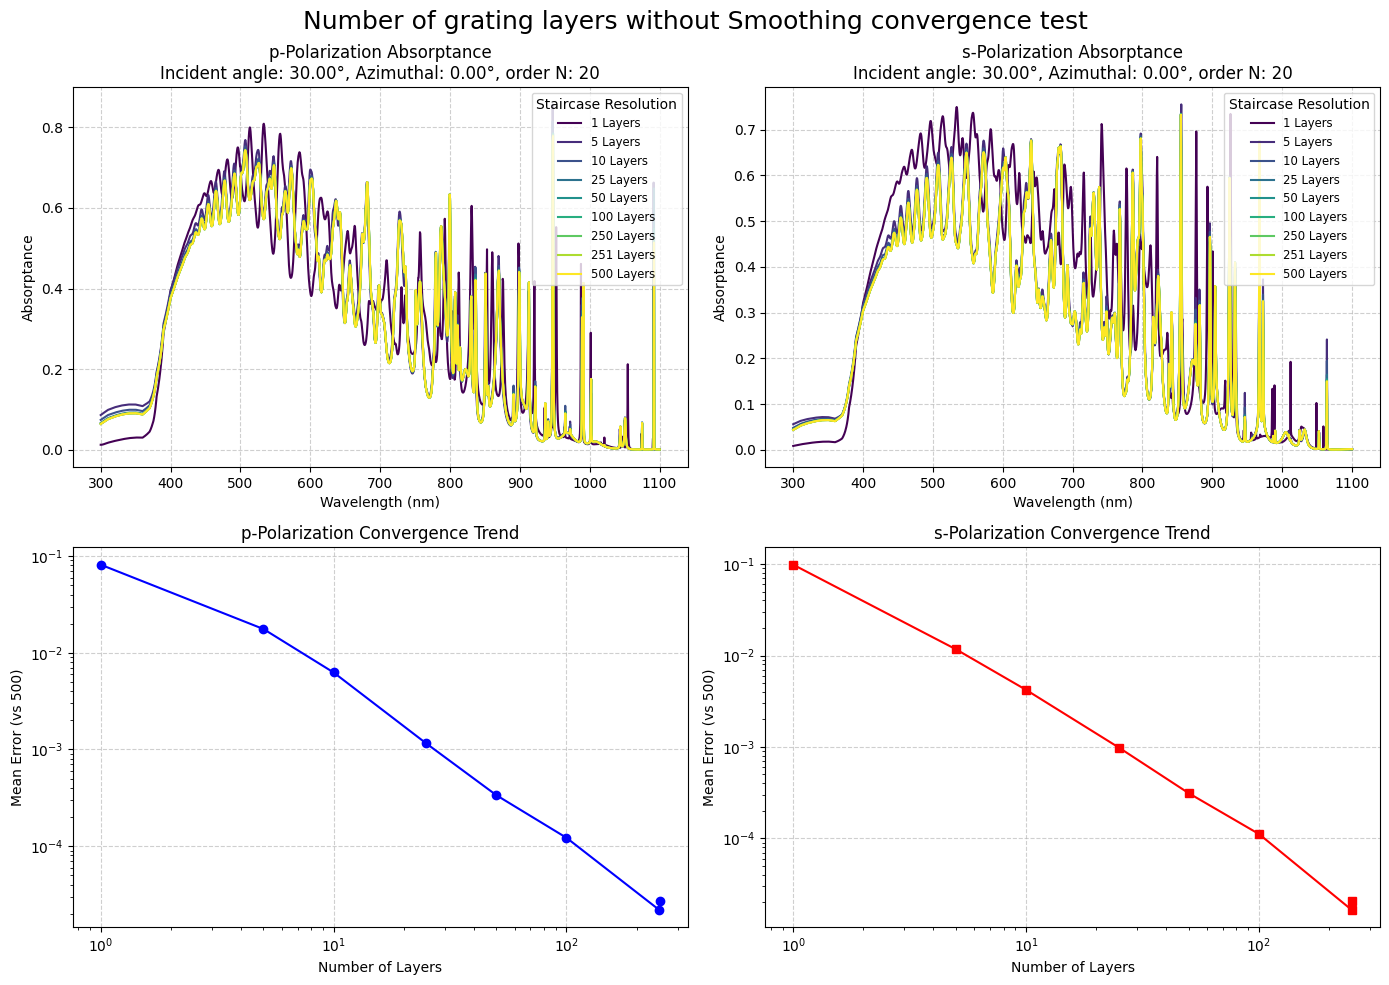

In [113]:
# Load the saved simulation data
saved_data = torch.load('../Data/AbsorptanceCurves/sweep_num_layers_no_subpixel_100nm_2026-06-09.pt', weights_only=False)
results = saved_data['results']
metadata = saved_data['metadata']

wavelengths = metadata['wavelengths']
inc_ang = metadata['config']['inc_ang']*180/np.pi
azi_ang = metadata['config']['azi_ang']*180/np.pi

layer_counts = []
key_map = {}

for key in results.keys():
    num = int(key.split('_')[-1])
    order_N = int(key.split('_')[2])
    layer_counts.append(num)
    key_map[num] = key

layer_counts = sorted(layer_counts)
best_layer_count = layer_counts[-1]
best_abs = results[key_map[best_layer_count]]['A_film']

# Pre-calculate mean errors
mean_errors_p = []
mean_errors_s = []
plot_layers = []

for num_layers in layer_counts:
    if num_layers == best_layer_count:
        continue
    curr_abs = results[key_map[num_layers]]['A_film']
    
    # Use torch functions instead of np functions on tensors
    err_p = torch.mean(torch.abs((curr_abs[:, 0] - best_abs[:, 0]))).item()
    err_s = torch.mean(torch.abs((curr_abs[:, 1] - best_abs[:, 1]))).item()
    
    mean_errors_p.append(err_p)
    mean_errors_s.append(err_s)
    plot_layers.append(num_layers)

# Create a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
(ax1_p, ax1_s), (ax2_p, ax2_s) = axs

colors = plt.cm.viridis(np.linspace(0, 1, len(layer_counts)))

for idx, num_layers in enumerate(layer_counts):
    curr_abs = results[key_map[num_layers]]['A_film']
    
    # Top Row: Plot spectra
    ax1_p.plot(wavelengths.cpu(), curr_abs[:, 0].cpu(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5)
    ax1_s.plot(wavelengths.cpu(), curr_abs[:, 1].cpu(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5)
# Format Top Row (Absorptance Spectra)
ax1_p.set_xlabel('Wavelength (nm)')
ax1_p.set_ylabel('Absorptance')
ax1_p.set_title(f'p-Polarization Absorptance\nIncident angle: {inc_ang:.2f}°, Azimuthal: {azi_ang:.2f}°, order N: {order_N}')
ax1_p.grid(True, linestyle='--', alpha=0.6)
ax1_p.legend(title='Staircase Resolution', loc='best', fontsize='small')
#ax1_p.set_yscale('log')

ax1_s.set_xlabel('Wavelength (nm)')
ax1_s.set_ylabel('Absorptance')
ax1_s.set_title(f's-Polarization Absorptance\nIncident angle: {inc_ang:.2f}°, Azimuthal: {azi_ang:.2f}°, order N: {order_N}')
ax1_s.grid(True, linestyle='--', alpha=0.6)
ax1_s.legend(title='Staircase Resolution', loc='best', fontsize='small')
#ax1_s.set_yscale('log')

# Format Bottom Row (Mean Error Convergence)
ax2_p.plot(plot_layers, mean_errors_p, marker='o', linestyle='-', color='blue')
ax2_p.set_xlabel('Number of Layers')
ax2_p.set_ylabel(f'Mean Error (vs {best_layer_count})')
ax2_p.set_title('p-Polarization Convergence Trend')
ax2_p.grid(True, linestyle='--', alpha=0.6)
ax2_p.set_yscale('log')
ax2_p.set_xscale('log')

ax2_s.plot(plot_layers, mean_errors_s, marker='s', linestyle='-', color='red')
ax2_s.set_xlabel('Number of Layers')
ax2_s.set_ylabel(f'Mean Error (vs {best_layer_count})')         
ax2_s.set_title('s-Polarization Convergence Trend')
ax2_s.grid(True, linestyle='--', alpha=0.6)
ax2_s.set_yscale('log')
ax2_s.set_xscale('log')

fig.suptitle('Number of grating layers without Smoothing convergence test',fontsize=18)
fig.tight_layout()
fig.savefig('../Data/Num_layer_no_subpixel_convergence_fig_100nm')
plt.show()  

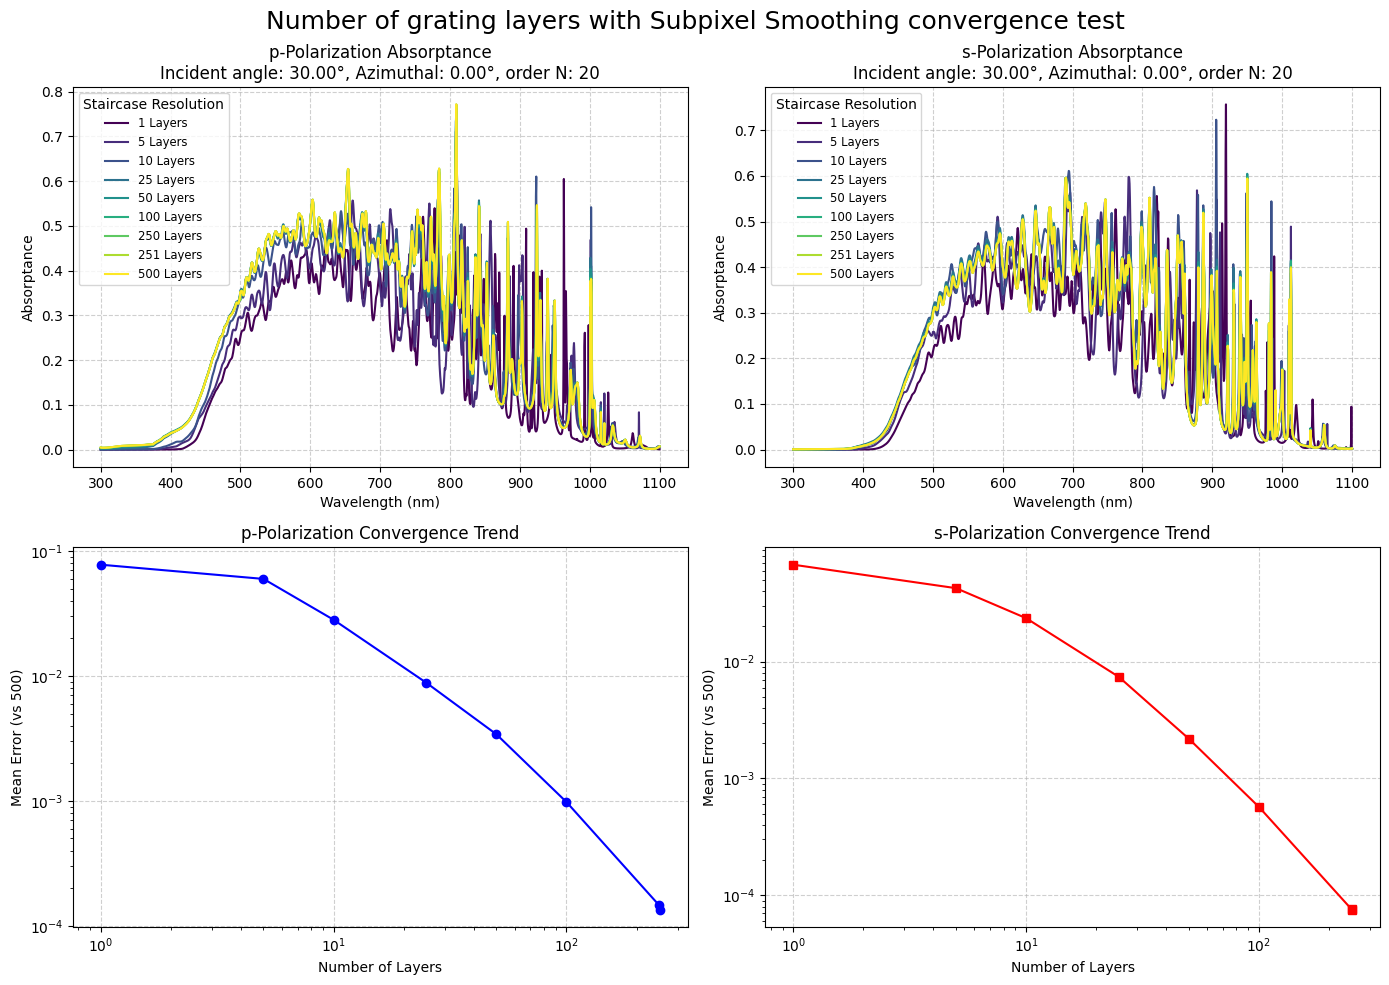

In [ ]:
# Load the saved simulation data
saved_data = torch.load('../Data/AbsorptanceCurves/sweep_num_layers_1000nm_2026-06-09.pt', weights_only=False)
results = saved_data['results']
metadata = saved_data['metadata']

wavelengths = metadata['wavelengths']
inc_ang = metadata['config']['inc_ang']*180/np.pi
azi_ang = metadata['config']['azi_ang']*180/np.pi

layer_counts = []
key_map = {}

for key in results.keys():
    num = int(key.split('_')[-1])
    order_N = int(key.split('_')[2])
    layer_counts.append(num)
    key_map[num] = key

layer_counts = sorted(layer_counts)
best_layer_count = layer_counts[-1]
best_abs = results[key_map[best_layer_count]]['A_film']

# Pre-calculate mean errors
mean_errors_p = []
mean_errors_s = []
plot_layers = []

for num_layers in layer_counts:
    if num_layers == best_layer_count:
        continue
    curr_abs = results[key_map[num_layers]]['A_film']
    
    # Use torch functions instead of np functions on tensors
    err_p = torch.mean(torch.abs((curr_abs[:, 0] - best_abs[:, 0]))).item()
    err_s = torch.mean(torch.abs((curr_abs[:, 1] - best_abs[:, 1]))).item()
    
    mean_errors_p.append(err_p)
    mean_errors_s.append(err_s)
    plot_layers.append(num_layers)

# Create a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
(ax1_p, ax1_s), (ax2_p, ax2_s) = axs

colors = plt.cm.viridis(np.linspace(0, 1, len(layer_counts)))

for idx, num_layers in enumerate(layer_counts):
    curr_abs = results[key_map[num_layers]]['A_film']
    
    # Top Row: Plot spectra
    ax1_p.plot(wavelengths.cpu(), curr_abs[:, 0].cpu(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5)
    ax1_s.plot(wavelengths.cpu(), curr_abs[:, 1].cpu(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5)
# Format Top Row (Absorptance Spectra)
ax1_p.set_xlabel('Wavelength (nm)')
ax1_p.set_ylabel('Absorptance')
ax1_p.set_title(f'p-Polarization Absorptance\nIncident angle: {inc_ang:.2f}°, Azimuthal: {azi_ang:.2f}°, order N: {order_N}')
ax1_p.grid(True, linestyle='--', alpha=0.6)
ax1_p.legend(title='Staircase Resolution', loc='best', fontsize='small')
#ax1_p.set_yscale('log')

ax1_s.set_xlabel('Wavelength (nm)')
ax1_s.set_ylabel('Absorptance')
ax1_s.set_title(f's-Polarization Absorptance\nIncident angle: {inc_ang:.2f}°, Azimuthal: {azi_ang:.2f}°, order N: {order_N}')
ax1_s.grid(True, linestyle='--', alpha=0.6)
ax1_s.legend(title='Staircase Resolution', loc='best', fontsize='small')
#ax1_s.set_yscale('log')

# Format Bottom Row (Mean Error Convergence)
ax2_p.plot(plot_layers, mean_errors_p, marker='o', linestyle='-', color='blue')
ax2_p.set_xlabel('Number of Layers')
ax2_p.set_ylabel(f'Mean Error (vs {best_layer_count})')
ax2_p.set_title('p-Polarization Convergence Trend')
ax2_p.grid(True, linestyle='--', alpha=0.6)
ax2_p.set_yscale('log')
ax2_p.set_xscale('log')

ax2_s.plot(plot_layers, mean_errors_s, marker='s', linestyle='-', color='red')
ax2_s.set_xlabel('Number of Layers')
ax2_s.set_ylabel(f'Mean Error (vs {best_layer_count})')         
ax2_s.set_title('s-Polarization Convergence Trend')
ax2_s.grid(True, linestyle='--', alpha=0.6)
ax2_s.set_yscale('log')
ax2_s.set_xscale('log')

fig.suptitle('Number of grating layers with Subpixel Smoothing convergence test',fontsize=18)
fig.tight_layout()
fig.savefig('../Data/Num_layer_convergence_fig_1000nm')
plt.show()

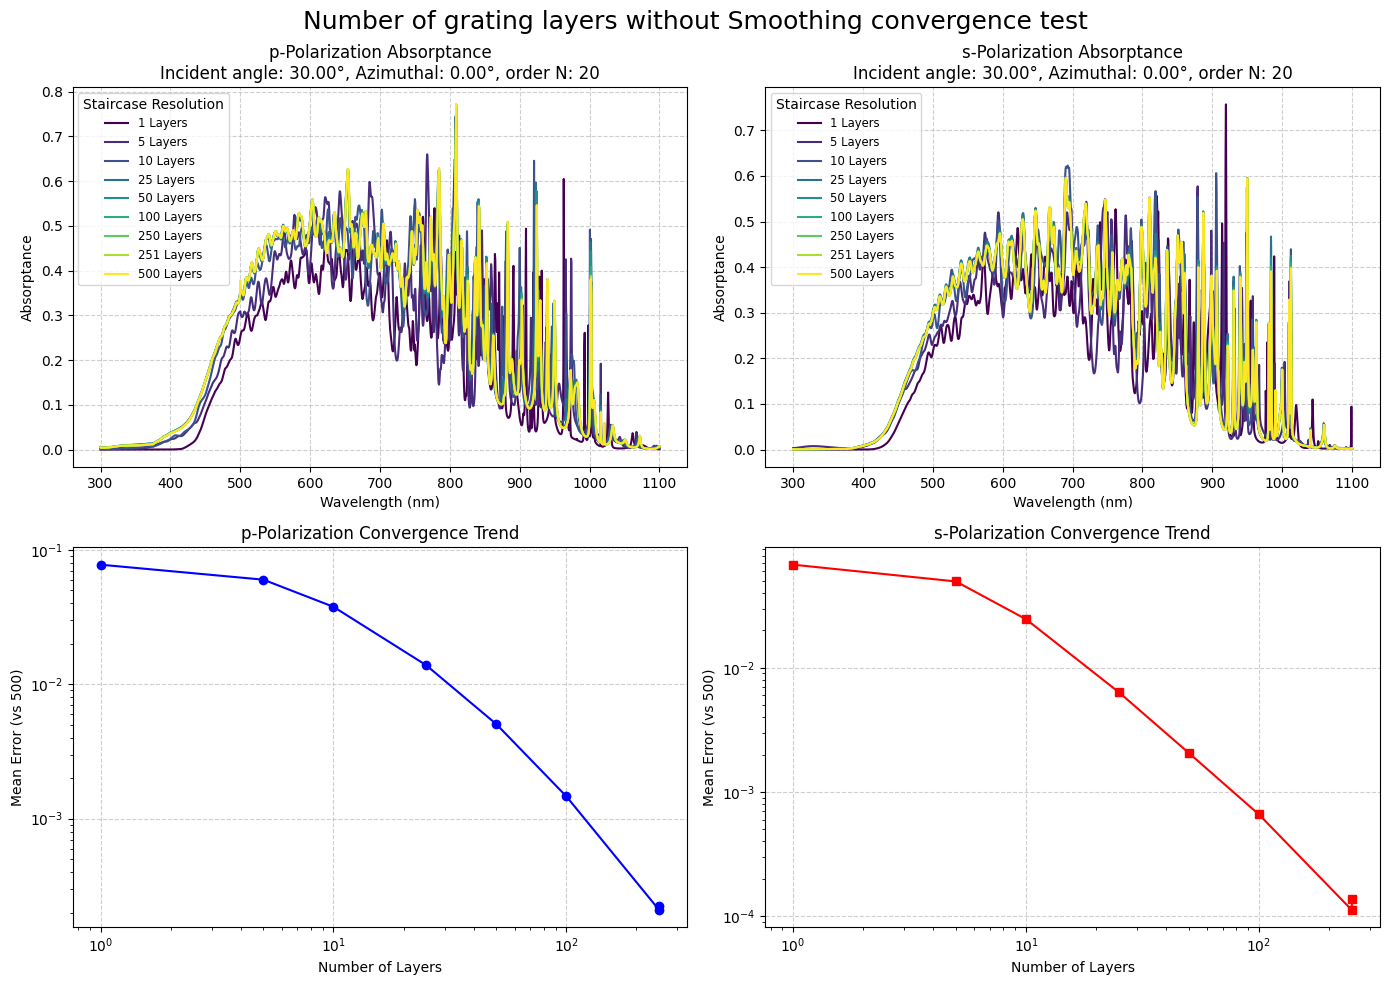

In [114]:
# Load the saved simulation data
saved_data = torch.load('../Data/AbsorptanceCurves/sweep_num_layers_no_subpixel_1000nm_2026-06-09.pt', weights_only=False)
results = saved_data['results']
metadata = saved_data['metadata']

wavelengths = metadata['wavelengths']
inc_ang = metadata['config']['inc_ang']*180/np.pi
azi_ang = metadata['config']['azi_ang']*180/np.pi

layer_counts = []
key_map = {}

for key in results.keys():
    num = int(key.split('_')[-1])
    order_N = int(key.split('_')[2])
    layer_counts.append(num)
    key_map[num] = key

layer_counts = sorted(layer_counts)
best_layer_count = layer_counts[-1]
best_abs = results[key_map[best_layer_count]]['A_film']

# Pre-calculate mean errors
mean_errors_p = []
mean_errors_s = []
plot_layers = []

for num_layers in layer_counts:
    if num_layers == best_layer_count:
        continue
    curr_abs = results[key_map[num_layers]]['A_film']
    
    # Use torch functions instead of np functions on tensors
    err_p = torch.mean(torch.abs((curr_abs[:, 0] - best_abs[:, 0]))).item()
    err_s = torch.mean(torch.abs((curr_abs[:, 1] - best_abs[:, 1]))).item()
    
    mean_errors_p.append(err_p)
    mean_errors_s.append(err_s)
    plot_layers.append(num_layers)

# Create a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
(ax1_p, ax1_s), (ax2_p, ax2_s) = axs

colors = plt.cm.viridis(np.linspace(0, 1, len(layer_counts)))

for idx, num_layers in enumerate(layer_counts):
    curr_abs = results[key_map[num_layers]]['A_film']
    
    # Top Row: Plot spectra
    ax1_p.plot(wavelengths.cpu(), curr_abs[:, 0].cpu(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5)
    ax1_s.plot(wavelengths.cpu(), curr_abs[:, 1].cpu(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5)
# Format Top Row (Absorptance Spectra)
ax1_p.set_xlabel('Wavelength (nm)')
ax1_p.set_ylabel('Absorptance')
ax1_p.set_title(f'p-Polarization Absorptance\nIncident angle: {inc_ang:.2f}°, Azimuthal: {azi_ang:.2f}°, order N: {order_N}')
ax1_p.grid(True, linestyle='--', alpha=0.6)
ax1_p.legend(title='Staircase Resolution', loc='best', fontsize='small')
#ax1_p.set_yscale('log')

ax1_s.set_xlabel('Wavelength (nm)')
ax1_s.set_ylabel('Absorptance')
ax1_s.set_title(f's-Polarization Absorptance\nIncident angle: {inc_ang:.2f}°, Azimuthal: {azi_ang:.2f}°, order N: {order_N}')
ax1_s.grid(True, linestyle='--', alpha=0.6)
ax1_s.legend(title='Staircase Resolution', loc='best', fontsize='small')
#ax1_s.set_yscale('log')

# Format Bottom Row (Mean Error Convergence)
ax2_p.plot(plot_layers, mean_errors_p, marker='o', linestyle='-', color='blue')
ax2_p.set_xlabel('Number of Layers')
ax2_p.set_ylabel(f'Mean Error (vs {best_layer_count})')
ax2_p.set_title('p-Polarization Convergence Trend')
ax2_p.grid(True, linestyle='--', alpha=0.6)
ax2_p.set_yscale('log')
ax2_p.set_xscale('log')

ax2_s.plot(plot_layers, mean_errors_s, marker='s', linestyle='-', color='red')
ax2_s.set_xlabel('Number of Layers')
ax2_s.set_ylabel(f'Mean Error (vs {best_layer_count})')         
ax2_s.set_title('s-Polarization Convergence Trend')
ax2_s.grid(True, linestyle='--', alpha=0.6)
ax2_s.set_yscale('log')
ax2_s.set_xscale('log')

fig.suptitle('Number of grating layers without Smoothing convergence test',fontsize=18)
fig.tight_layout()
fig.savefig('../Data/Num_layer_no_subpixel_convergence_fig_1000nm')
plt.show()  

#### compare to comsol

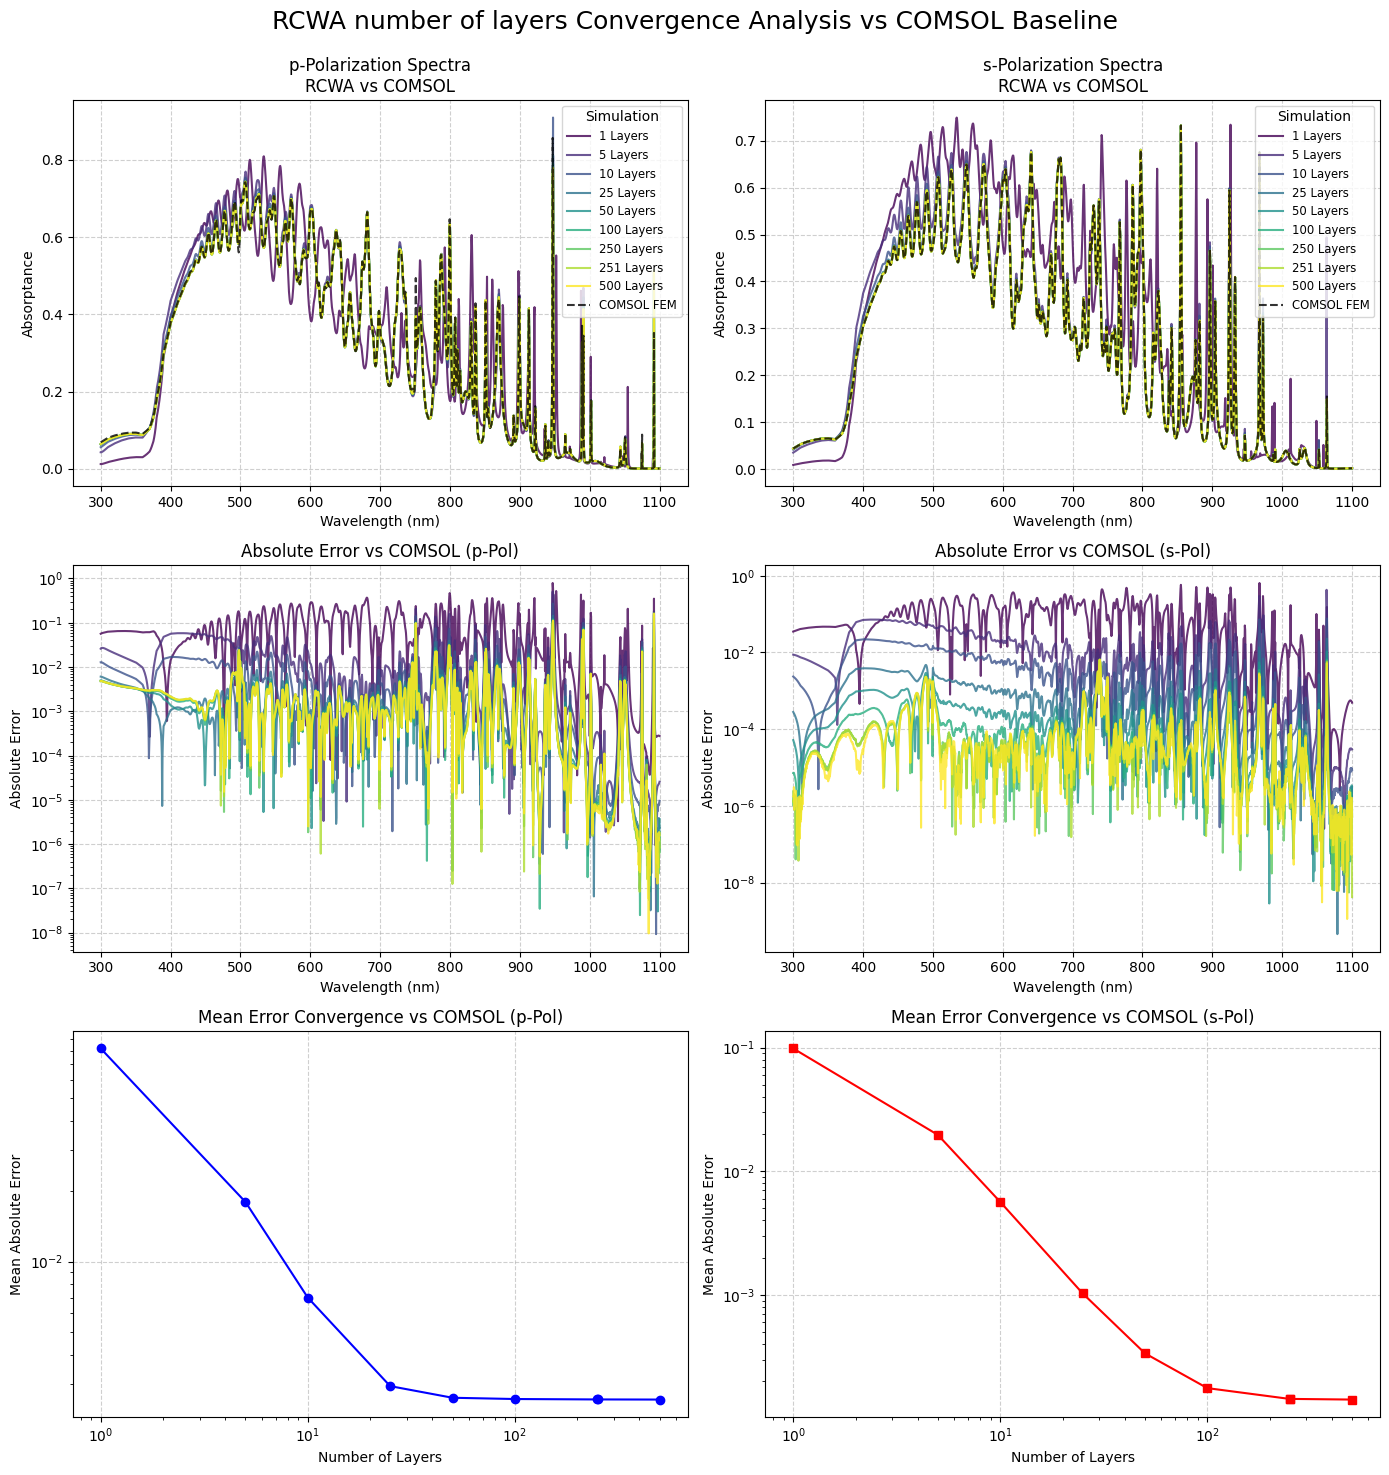

In [129]:
# ---------------------------------------------------------
# 1. Load the Data
# ---------------------------------------------------------
# Load RCWA Data
saved_data = torch.load('../Data/AbsorptanceCurves/sweep_num_layers_100nm_2026-06-09.pt', weights_only=False)
results = saved_data['results']
metadata = saved_data['metadata']

wavelengths = metadata['wavelengths'].cpu().numpy()
inc_ang = metadata['config']['inc_ang']*180/np.pi
azi_ang = metadata['config']['azi_ang']*180/np.pi

layer_counts = []
key_map = {}
for key in results.keys():
    num = int(key.split('_')[-1])
    layer_counts.append(num)
    key_map[num] = key

layer_counts = sorted(layer_counts)
best_layer_count = layer_counts[-1]

# Load COMSOL Data
# IMPORTANT: Update the p-pol filepath to match your actual COMSOL export file
comsol_data_s = np.loadtxt('/home/an/Documents/COMSOL/mph files/light_trapping_layer/Absorptance_curve_with_IBC_100_nm_spol.txt', comments='%')
comsol_data_p = np.loadtxt('/home/an/Documents/COMSOL/mph files/light_trapping_layer/Absorptance_curve_with_IBC_100_nm_ppol.txt', comments='%')

comsol_wavelengths = comsol_data_s[:, 0]
comsol_abs_s = comsol_data_s[:, 2]
comsol_abs_p = comsol_data_p[:, 2]

# ---------------------------------------------------------
# 2. Pre-calculate Mean Errors vs COMSOL
# ---------------------------------------------------------
mean_errors_p_vs_comsol = []
mean_errors_s_vs_comsol = []

for num_layers in layer_counts:
    curr_abs = results[key_map[num_layers]]['A_film'].cpu().numpy()
    
    # Direct subtraction relies on matching wavelength grids
    err_p = np.mean(np.abs(curr_abs[:, 0] - comsol_abs_p))
    err_s = np.mean(np.abs(curr_abs[:, 1] - comsol_abs_s))
    
    mean_errors_p_vs_comsol.append(err_p)
    mean_errors_s_vs_comsol.append(err_s)

# ---------------------------------------------------------
# 3. Create the 3x2 Plot
# ---------------------------------------------------------
fig, axs = plt.subplots(3, 2, figsize=(14, 15))
(ax1_p, ax1_s), (ax2_p, ax2_s), (ax3_p, ax3_s) = axs

colors = plt.cm.viridis(np.linspace(0, 1, len(layer_counts)))

for idx, num_layers in enumerate(layer_counts):
    curr_abs = results[key_map[num_layers]]['A_film'].cpu().numpy()
    rcwa_p = curr_abs[:, 0]
    rcwa_s = curr_abs[:, 1]
    
    # --- Row 1: Absorptance Spectra ---
    ax1_p.plot(wavelengths, rcwa_p, label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5, alpha=0.8)
    ax1_s.plot(wavelengths, rcwa_s, label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5, alpha=0.8)
    
    # --- Row 2: Error Spectra vs COMSOL ---
    ax2_p.plot(wavelengths, np.abs(comsol_abs_p - rcwa_p), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5, alpha=0.8)
    ax2_s.plot(wavelengths, np.abs(comsol_abs_s - rcwa_s), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5, alpha=0.8)

# --- Overlay COMSOL Baselines & Zero Lines ---
# Row 1 Baselines
ax1_p.plot(comsol_wavelengths, comsol_abs_p, label='COMSOL FEM', color='black', alpha=0.8, linestyle='--', linewidth=1.5)
ax1_s.plot(comsol_wavelengths, comsol_abs_s, label='COMSOL FEM', color='black', alpha=0.8, linestyle='--', linewidth=1.5)

# Row 2 Zero Lines (Ideal Error)
ax2_p.axhline(0, color='black', alpha=0.8, linestyle='--', linewidth=1.5, label='Zero Error')
ax2_s.axhline(0, color='black', alpha=0.8, linestyle='--', linewidth=1.5, label='Zero Error')

# --- Formatting Row 1 (Spectra) ---
ax1_p.set_title(f'p-Polarization Spectra\nRCWA vs COMSOL')
ax1_p.set_ylabel('Absorptance')
ax1_p.grid(True, linestyle='--', alpha=0.6)
ax1_p.legend(title='Simulation', loc='best', fontsize='small')

ax1_s.set_title(f's-Polarization Spectra\nRCWA vs COMSOL')
ax1_s.set_ylabel('Absorptance')
ax1_s.grid(True, linestyle='--', alpha=0.6)
ax1_s.legend(title='Simulation', loc='best', fontsize='small')

# --- Formatting Row 2 (Error Spectra) ---
ax2_p.set_title('Absolute Error vs COMSOL (p-Pol)')
ax2_p.set_ylabel('Absolute Error')
ax2_p.set_yscale('log')
ax2_p.grid(True, linestyle='--', alpha=0.6)

ax2_s.set_title('Absolute Error vs COMSOL (s-Pol)')
ax2_s.set_ylabel('Absolute Error')
ax2_s.set_yscale('log')
ax2_s.grid(True, linestyle='--', alpha=0.6)

# --- Formatting Row 3 (Convergence Trend) ---
ax3_p.plot(layer_counts, mean_errors_p_vs_comsol, marker='o', linestyle='-', color='blue')
ax3_p.set_title('Mean Error Convergence vs COMSOL (p-Pol)')
ax3_p.set_xlabel('Number of Layers')
ax3_p.set_ylabel('Mean Absolute Error')
ax3_p.set_xscale('log')
ax3_p.set_yscale('log')
ax3_p.grid(True, linestyle='--', alpha=0.6)

ax3_s.plot(layer_counts, mean_errors_s_vs_comsol, marker='s', linestyle='-', color='red')
ax3_s.set_title('Mean Error Convergence vs COMSOL (s-Pol)')
ax3_s.set_xlabel('Number of Layers')
ax3_s.set_ylabel('Mean Absolute Error')
ax3_s.set_xscale('log')
ax3_s.set_yscale('log')
ax3_s.grid(True, linestyle='--', alpha=0.6)

# Provide bottom x-labels for the columns
for ax in [ax1_p, ax1_s, ax2_p, ax2_s]:
    ax.set_xlabel('Wavelength (nm)')

fig.suptitle('RCWA number of layers Convergence Analysis vs COMSOL Baseline', fontsize=18)
fig.tight_layout()
fig.subplots_adjust(top=0.92)  # Adjust top spacing for the suptitle
fig.savefig('../Data/RCWA_vs_COMSOL_Full_Comparison_num_layers_100nm.png')
plt.show()

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Load the Data
# ---------------------------------------------------------
# Load RCWA Data
saved_data = torch.load('../Data/AbsorptanceCurves/sweep_order_N_2026-06-03.pt', weights_only=False)
results = saved_data['results']
metadata = saved_data['metadata']

wavelengths = metadata['wavelengths'].cpu().numpy()
inc_ang = metadata['inc_ang_deg']
azi_ang = metadata['azi_ang_deg']

order_Ns = []
key_map = {}
for key in results.keys():
    num = int(key.split('_')[2])
    order_Ns.append(num)
    key_map[num] = key

order_Ns = sorted(order_Ns)
best_order = order_Ns[-1]

# Load COMSOL Data
comsol_data_s = np.loadtxt('/home/an/Documents/COMSOL/mph files/light_trapping_layer/outputs/Absorptance_curve_with_IBC_spol.txt', comments='%')
comsol_data_p = np.loadtxt('/home/an/Documents/COMSOL/mph files/light_trapping_layer/outputs/Absorptance_curve_with_IBC_ppol.txt', comments='%')

comsol_wavelengths = comsol_data_s[:, 0]
comsol_abs_s = comsol_data_s[:, 4]
comsol_abs_p = comsol_data_p[:, 2]

# ---------------------------------------------------------
# 2. Pre-calculate Mean Errors vs COMSOL
# ---------------------------------------------------------
mean_errors_p_vs_comsol = []
mean_errors_s_vs_comsol = []

for order_N in order_Ns:
    curr_abs = results[key_map[order_N]]['A_film'].cpu().numpy()
    
    # Direct subtraction relies on matching wavelength grids
    err_p = np.mean(np.abs(curr_abs[:, 0] - comsol_abs_p))
    err_s = np.mean(np.abs(curr_abs[:, 1] - comsol_abs_s))
    
    mean_errors_p_vs_comsol.append(err_p)
    mean_errors_s_vs_comsol.append(err_s)

# ---------------------------------------------------------
# 3. Create the 3x2 Plot
# ---------------------------------------------------------
fig, axs = plt.subplots(3, 2, figsize=(14, 15))
(ax1_p, ax1_s), (ax2_p, ax2_s), (ax3_p, ax3_s) = axs

colors = plt.cm.viridis(np.linspace(0, 1, len(order_Ns)))

for idx, order_N in enumerate(order_Ns):
    curr_abs = results[key_map[order_N]]['A_film'].cpu().numpy()
    rcwa_p = curr_abs[:, 0]
    rcwa_s = curr_abs[:, 1]
    
    # --- Row 1: Absorptance Spectra ---
    ax1_p.plot(wavelengths, rcwa_p, label=f'N = {order_N}', color=colors[idx], linewidth=1.5, alpha=0.8)
    ax1_s.plot(wavelengths, rcwa_s, label=f'N = {order_N}', color=colors[idx], linewidth=1.5, alpha=0.8)
    
    # --- Row 2: Error Spectra vs COMSOL ---
    ax2_p.plot(wavelengths, np.abs(comsol_abs_p - rcwa_p), label=f'N = {order_N}', color=colors[idx], linewidth=1.5, alpha=0.8)
    ax2_s.plot(wavelengths, np.abs(comsol_abs_s - rcwa_s), label=f'N = {order_N}', color=colors[idx], linewidth=1.5, alpha=0.8)

# --- Overlay COMSOL Baselines & Zero Lines ---
# Row 1 Baselines
ax1_p.plot(comsol_wavelengths, comsol_abs_p, label='COMSOL FEM', color='black', alpha=0.8, linestyle='--', linewidth=1.5)
ax1_s.plot(comsol_wavelengths, comsol_abs_s, label='COMSOL FEM', color='black', alpha=0.8, linestyle='--', linewidth=1.5)

# Row 2 Zero Lines (Ideal Error)
ax2_p.axhline(0, color='black', alpha=0.8, linestyle='--', linewidth=1.5, label='Zero Error')
ax2_s.axhline(0, color='black', alpha=0.8, linestyle='--', linewidth=1.5, label='Zero Error')

# --- Formatting Row 1 (Spectra) ---
ax1_p.set_title(f'p-Polarization Spectra\nRCWA vs COMSOL')
ax1_p.set_ylabel('Absorptance')
ax1_p.grid(True, linestyle='--', alpha=0.6)
ax1_p.legend(title='Fourier Orders', loc='best', fontsize='small')

ax1_s.set_title(f's-Polarization Spectra\nRCWA vs COMSOL')
ax1_s.set_ylabel('Absorptance')
ax1_s.grid(True, linestyle='--', alpha=0.6)
ax1_s.legend(title='Fourier Orders', loc='best', fontsize='small')

# --- Formatting Row 2 (Error Spectra) ---
ax2_p.set_title('Absolute Error vs COMSOL (p-Pol)')
ax2_p.set_ylabel('Absolute Error')
ax2_p.set_yscale('log')
ax2_p.grid(True, linestyle='--', alpha=0.6)

ax2_s.set_title('Absolute Error vs COMSOL (s-Pol)')
ax2_s.set_ylabel('Absolute Error')
ax2_s.set_yscale('log')
ax2_s.grid(True, linestyle='--', alpha=0.6)

# --- Formatting Row 3 (Convergence Trend) ---
ax3_p.plot(order_Ns, mean_errors_p_vs_comsol, marker='o', linestyle='-', color='blue')
ax3_p.set_title('Mean Error Convergence vs COMSOL (p-Pol)')
ax3_p.set_xlabel('Number of Fourier Orders (N)')
ax3_p.set_ylabel('Mean Absolute Error')
ax3_p.set_xscale('log')
ax3_p.set_yscale('log')
ax3_p.grid(True, linestyle='--', alpha=0.6)

ax3_s.plot(order_Ns, mean_errors_s_vs_comsol, marker='s', linestyle='-', color='red')
ax3_s.set_title('Mean Error Convergence vs COMSOL (s-Pol)')
ax3_s.set_xlabel('Number of Fourier Orders (N)')
ax3_s.set_ylabel('Mean Absolute Error')
ax3_s.set_xscale('log')
ax3_s.set_yscale('log')
ax3_s.grid(True, linestyle='--', alpha=0.6)

# Provide bottom x-labels for the columns
for ax in [ax1_p, ax1_s, ax2_p, ax2_s]:
    ax.set_xlabel('Wavelength (nm)')

fig.suptitle('RCWA Fourier Order Convergence Analysis vs COMSOL Baseline', fontsize=18)
fig.tight_layout()
fig.subplots_adjust(top=0.92)  # Adjust top spacing for the suptitle
fig.savefig('../Data/RCWA_vs_COMSOL_Order_N_Full_Comparison.png')
plt.show()

### *Fourier* Order

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Load the saved simulation data
saved_data = torch.load('../Data/AbsorptanceCurves/sweep_order_N_2026-06-03.pt', weights_only=False)
results = saved_data['results']
metadata = saved_data['metadata']

wavelengths = metadata['wavelengths']
inc_ang = metadata['inc_ang_deg']
azi_ang = metadata['azi_ang_deg']

# Create the key map for order_N
order_Ns = []
key_map = {}

for key in results.keys():
    # Extracts the integer value from keys like 'order_10' or 'sweep_10'
    num = int(key.split('_')[2])
    order_Ns.append(num)
    num_layers = int(key.split('_')[-1])
    key_map[num] = key

order_Ns = sorted(order_Ns)
best_order = order_Ns[-1]
best_abs = results[key_map[best_order]]['A_film']

# Pre-calculate mean relative errors
mean_errors_p = []
mean_errors_s = []
plot_orders = []

for order_N in order_Ns:
    if order_N == best_order:
        continue
    curr_abs = results[key_map[order_N]]['A_film']
    
    # Calculate relative error to the highest Fourier order
    err_p = torch.mean(torch.abs((curr_abs[:, 0] - best_abs[:, 0]) / (best_abs[:, 0] + 1e-12))).item()
    err_s = torch.mean(torch.abs((curr_abs[:, 1] - best_abs[:, 1]) / (best_abs[:, 1] + 1e-12))).item()
    
    mean_errors_p.append(err_p)
    mean_errors_s.append(err_s)
    plot_orders.append(order_N)

# Create a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
(ax1_p, ax1_s), (ax2_p, ax2_s) = axs

colors = plt.cm.viridis(np.linspace(0, 1, len(order_Ns)))

for idx, order_N in enumerate(order_Ns):
    curr_abs = results[key_map[order_N]]['A_film']
    
    # Top Row: Plot spectra
    ax1_p.plot(wavelengths.cpu(), curr_abs[:, 0].cpu(), label=f'N = {order_N}', color=colors[idx], linewidth=1.5)
    ax1_s.plot(wavelengths.cpu(), curr_abs[:, 1].cpu(), label=f'N = {order_N}', color=colors[idx], linewidth=1.5)

# Format Top Row (Absorptance Spectra)
ax1_p.set_xlabel('Wavelength (nm)')
ax1_p.set_ylabel('Absorptance')
ax1_p.set_title(f'p-Polarization Absorptance\nIncident: {inc_ang:.2f}°, Azimuthal: {azi_ang:.2f}°, num layers: {num_layers}')
ax1_p.grid(True, linestyle='--', alpha=0.6)
ax1_p.legend(title='Fourier Orders', loc='best', fontsize='small')

ax1_s.set_xlabel('Wavelength (nm)')
ax1_s.set_ylabel('Absorptance')
ax1_s.set_title(f's-Polarization Absorptance\nIncident: {inc_ang:.2f}°, Azimuthal: {azi_ang:.2f}°, num layers: {num_layers}')
ax1_s.grid(True, linestyle='--', alpha=0.6)
ax1_s.legend(title='Fourier Orders', loc='best', fontsize='small')

# Format Bottom Row (Mean Error Convergence)
ax2_p.plot(plot_orders, mean_errors_p, marker='o', linestyle='-', color='blue')
ax2_p.set_xlabel('Number of Fourier Orders (N)')
ax2_p.set_ylabel(f'Mean Relative Error (vs N={best_order})')
ax2_p.set_title('p-Polarization Convergence Trend')
ax2_p.grid(True, linestyle='--', alpha=0.6)
ax2_p.set_yscale('log')
ax2_p.set_xscale('log')

ax2_s.plot(plot_orders, mean_errors_s, marker='s', linestyle='-', color='red')
ax2_s.set_xlabel('Number of Fourier Orders (N)')
ax2_s.set_ylabel(f'Mean Relative Error (vs N={best_order})')
ax2_s.set_title('s-Polarization Convergence Trend')
ax2_s.grid(True, linestyle='--', alpha=0.6)
ax2_s.set_yscale('log')
ax2_s.set_xscale('log')

fig.suptitle('Number of fourier orders with Subpixel Smoothing convergence test',fontsize=18)
fig.tight_layout()
fig.savefig('../Data/Order_N_convergence_fig.png')
plt.show()